In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("data/listings_spatial.csv")
df = df.dropna(subset=["price"])
df.shape

(7426, 6)

In [3]:
feature_cols = ["latitude", "longitude", "district_group"]
X = df[feature_cols]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), ["latitude", "longitude"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["district_group"]),
])

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 5940, Test: 1486


## Baseline-Model

In [4]:
baseline = Pipeline([
    ("preprocess", preprocess),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="distance")),
])
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 68.44488047372069
R2: -0.14727978526927488


## predicted vs. real

In [5]:
sample = pd.DataFrame({"actual": y_test, "predicted": y_pred}).sample(10, random_state=42)
sample["error"] = (sample["actual"] - sample["predicted"]).abs()
sample

,actual,predicted,error
4956,40.0,36.000000,4.000000
6072,104.0,225.186921,121.186921
1087,143.0,215.615956,72.615956
4028,671.0,134.003123,536.996877
5965,124.0,85.532726,38.467274
247,91.0,117.099169,26.099169
4382,228.0,195.583756,32.416244
45,88.0,132.142834,44.142834
811,125.0,136.000000,11.000000
1215,133.0,131.722688,1.277312


## Hyperparameters

In [6]:
pipe = Pipeline([
    ("preprocess", preprocess),
    ("knn", KNeighborsRegressor()),
])

param_grid = {
    "knn__n_neighbors": [1, 2, 3, 5, 7, 10, 15, 20, 30, 50],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Beste Parameter:", grid_search.best_params_)
print("Bester CV-MAE:", -grid_search.best_score_)

Beste Parameter: {'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}
Bester CV-MAE: 62.823283112825685


In [7]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["mae"] = -cv_results["mean_test_score"]
cv_results = cv_results[["param_knn__n_neighbors", "param_knn__weights", "param_knn__p", "mae"]]
cv_results = cv_results.sort_values("mae")
cv_results.columns = ["k", "weights", "p", "mae"]
cv_results.reset_index(drop=True)

,k,weights,p,mae
0,50,distance,2,62.823283
1,50,distance,1,62.840090
2,30,distance,2,63.397836
3,30,distance,1,63.479526
4,20,distance,1,64.193442
5,20,distance,2,64.205712
6,15,distance,2,64.828342
7,15,distance,1,64.931703
8,50,uniform,1,65.094960
9,50,uniform,2,65.143441


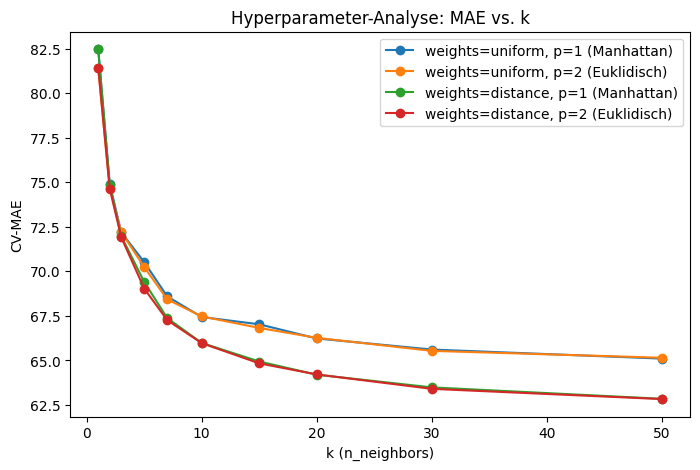

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for weights in ["uniform", "distance"]:
    for p in [1, 2]:
        subset = cv_results[(cv_results["weights"] == weights) & (cv_results["p"] == p)].sort_values("k")
        label = f"weights={weights}, p={p} ({'Manhattan' if p == 1 else 'Euklidisch'})"
        ax.plot(subset["k"], subset["mae"], marker="o", label=label)

ax.set_xlabel("k (n_neighbors)")
ax.set_ylabel("CV-MAE")
ax.set_title("Hyperparameter-Analyse: MAE vs. k")
ax.legend()
plt.show()

## Test final Model

In [9]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Beste Parameter:", grid_search.best_params_)
print("Test-MAE:", mean_absolute_error(y_test, y_pred_best))
print("Test-R2:", r2_score(y_test, y_pred_best))

Beste Parameter: {'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}
Test-MAE: 62.1395160028305
Test-R2: 0.05090508172454855


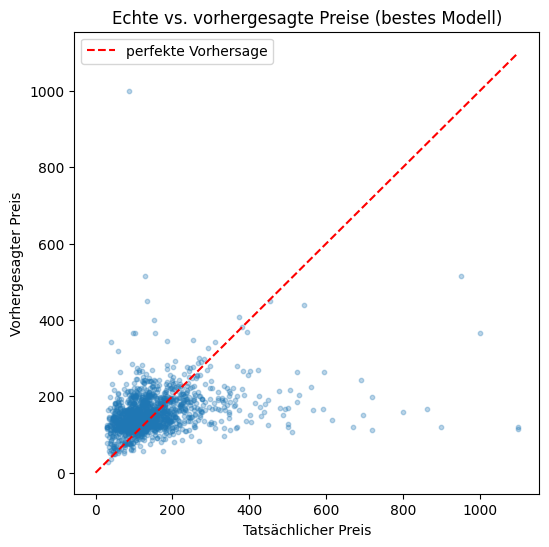

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.3, s=10)
lims = [0, max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="perfekte Vorhersage")
ax.set_xlabel("Tatsächlicher Preis")
ax.set_ylabel("Vorhergesagter Preis")
ax.set_title("Echte vs. vorhergesagte Preise (bestes Modell)")
ax.legend()
plt.show()